Download Dataset: https://www.kaggle.com/datasets/purusinghvi/email-spam-classification-dataset/data

# Naive Bayes

In [1]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Contoh data email
emails = [
    'free offer win cash now', 
    'urgent work opportunity', 
    'win a prize now',
    'meet the new colleague tomorrow', 
    'free vacation offers', 
    'work assignment details'
]
labels = ['spam', 'ham', 'spam', 'ham', 'spam', 'ham']

# Mengubah teks menjadi fitur numerik menggunakan CountVectorizer
vectorizer = CountVectorizer()
X = vectorizer.fit_transform(emails)
y = labels

# Pisahkan data menjadi training dan testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

# Bangun model Naive Bayes
nb = MultinomialNB()
nb.fit(X_train, y_train)

# Prediksi dengan data uji
y_pred = nb.predict(X_test)

# Evaluasi model
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:")
print(classification_report(y_test, y_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 1.0
Classification Report:
              precision    recall  f1-score   support

         ham       1.00      1.00      1.00         1
        spam       1.00      1.00      1.00         1

    accuracy                           1.00         2
   macro avg       1.00      1.00      1.00         2
weighted avg       1.00      1.00      1.00         2

Confusion Matrix:
[[1 0]
 [0 1]]


# Implementasi Spam Email TREC Public Spam Corpus and Enron-Spam Dataset

## Import Packages

In [2]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
import pandas as pd
import numpy as np

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical

import seaborn as sns

In [4]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [5]:
import re
import string
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from wordcloud import WordCloud

import nltk 
nltk.download('punkt')
nltk.download('stopwords')


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\berwyn\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\berwyn\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

## Loading Data

In [6]:
df = pd.read_csv('Data/combined_data.csv')

In [7]:
df.head()

,label,text
0,1,ounce feather bowl hummingbird opec moment ala...
1,1,wulvob get your medircations online qnb ikud v...
2,0,computer connection from cnn com wednesday es...
3,1,university degree obtain a prosperous future m...
4,0,thanks for all your answers guys i know i shou...


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 83448 entries, 0 to 83447
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   label   83448 non-null  int64 
 1   text    83448 non-null  object
dtypes: int64(1), object(1)
memory usage: 1.3+ MB


In [9]:
df.shape

(83448, 2)

## Data Preprocessing

In [10]:
df.isnull().sum()

label    0
text     0
dtype: int64

In [11]:
df['label'].unique()

array([1, 0], dtype=int64)

In [12]:
df['text'].duplicated().sum()

2

In [13]:
df.drop_duplicates(subset=['text'], inplace=True)

In [14]:
def preprocess_text(text):
    if isinstance(text, str):
        text = text.lower()
        text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
        text = re.sub(r'@\w+', '', text)
        text = re.sub(r'#\w+', '', text)
        text = re.sub(r'[^\w\s]', '', text)
        text = re.sub(r'\d+', '', text)
        text = re.sub(r'\s+', ' ', text).strip()
        tokens = nltk.word_tokenize(text)

        stop_words = set(stopwords.words('english'))
        tokens = [word for word in tokens if word not in stop_words]

        lemmatizer = WordNetLemmatizer()
        tokens = [lemmatizer.lemmatize(word) for word in tokens]

        text = ' '.join(tokens)

        return text
    else:
        return ""

In [15]:
df['processed_text'] = df['text'].apply(preprocess_text)
df[['text', 'processed_text']].head()

,text,processed_text
0,ounce feather bowl hummingbird opec moment ala...,ounce feather bowl hummingbird opec moment ala...
1,wulvob get your medircations online qnb ikud v...,wulvob get medircations online qnb ikud viagra...
2,computer connection from cnn com wednesday es...,computer connection cnn com wednesday escapenu...
3,university degree obtain a prosperous future m...,university degree obtain prosperous future mon...
4,thanks for all your answers guys i know i shou...,thanks answer guy know checked rsync manual wo...


## Splitting Data

In [25]:
X_train, X_test, y_train, y_test = train_test_split(df['text'], df['label'], test_size=0.2, random_state=42)

In [26]:
vectorizer=CountVectorizer()
X_train=vectorizer.fit_transform(X_train)

## Building Model

In [27]:
classifier=MultinomialNB()
classifier.fit(X_train, y_train)

MultinomialNB()

In [28]:
X_test=vectorizer.transform(X_test)

In [29]:
X_test.shape

(16690, 275154)

In [30]:
y_pred=classifier.predict(X_test)

In [31]:
classifier.score(X_test, y_test)

0.9756740563211503

In [32]:
abs(y_pred - y_test).sum()

406

In [33]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.97      0.98      0.97      7880
           1       0.99      0.97      0.98      8810

    accuracy                           0.98     16690
   macro avg       0.98      0.98      0.98     16690
weighted avg       0.98      0.98      0.98     16690



<Axes: >

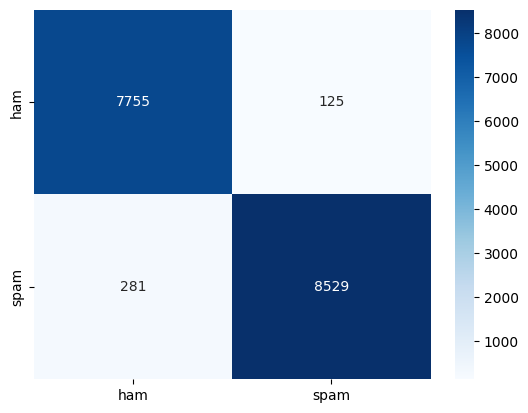

In [34]:
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues', xticklabels=['ham', 'spam'], yticklabels=['ham', 'spam'])